### **step 2 data collection and understanding it**
This dataset consists of 128069 rows and 21 columns, data types are mostly ints, floats and objects.


In [ ]:
#the libraries needed for the project
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
#to load the data directly from the project drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv("/content/shot_logs.csv")

In [ ]:
#the first 5 lines of the dataset
df.head(5)

,GAME_ID,MATCHUP,LOCATION,W,FINAL_MARGIN,SHOT_NUMBER,PERIOD,GAME_CLOCK,SHOT_CLOCK,DRIBBLES,...,SHOT_DIST,PTS_TYPE,SHOT_RESULT,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,FGM,PTS,player_name,player_id
0,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,1,1,1:09,10.8,2,...,7.7,2,made,"Anderson, Alan",101187,1.3,1,2,brian roberts,203148
1,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,2,1,0:14,3.4,0,...,28.2,3,missed,"Bogdanovic, Bojan",202711,6.1,0,0,brian roberts,203148
2,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,3,1,0:00,NaN,3,...,10.1,2,missed,"Bogdanovic, Bojan",202711,0.9,0,0,brian roberts,203148
3,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,4,2,11:47,10.3,2,...,17.2,2,missed,"Brown, Markel",203900,3.4,0,0,brian roberts,203148
4,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,5,2,10:34,10.9,2,...,3.7,2,missed,"Young, Thaddeus",201152,1.1,0,0,brian roberts,203148


In [ ]:
#how many rows and columns the dataset has
df.shape


(128069, 21)

In [ ]:
#info about the dataset like data type and non null values and column names
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128069 entries, 0 to 128068
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   GAME_ID                     128069 non-null  int64  
 1   MATCHUP                     128069 non-null  object 
 2   LOCATION                    128069 non-null  object 
 3   W                           128069 non-null  object 
 4   FINAL_MARGIN                128069 non-null  int64  
 5   SHOT_NUMBER                 128069 non-null  int64  
 6   PERIOD                      128069 non-null  int64  
 7   GAME_CLOCK                  128069 non-null  object 
 8   SHOT_CLOCK                  122502 non-null  float64
 9   DRIBBLES                    128069 non-null  int64  
 10  TOUCH_TIME                  128069 non-null  float64
 11  SHOT_DIST                   128069 non-null  float64
 12  PTS_TYPE                    128069 non-null  int64  
 13  SHOT_RESULT   

In [ ]:
df.describe()

,GAME_ID,FINAL_MARGIN,SHOT_NUMBER,PERIOD,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,SHOT_DIST,PTS_TYPE,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,FGM,PTS,player_id
count,1.280690e+05,128069.000000,128069.000000,128069.000000,122502.000000,128069.000000,128069.000000,128069.000000,128069.000000,128069.000000,128069.000000,128069.000000,128069.000000,128069.000000
mean,2.140045e+07,0.208723,6.506899,2.469427,12.453344,2.023355,2.765901,13.571504,2.264670,159038.487284,4.123015,0.452139,0.997314,157238.251247
std,2.578773e+02,13.233267,4.713260,1.139919,5.763265,3.477760,3.043682,8.888964,0.441159,78791.172947,2.756446,0.497706,1.130978,79362.389336
min,2.140000e+07,-53.000000,1.000000,1.000000,0.000000,0.000000,-163.600000,0.000000,2.000000,708.000000,0.000000,0.000000,0.000000,708.000000
25%,2.140023e+07,-8.000000,3.000000,1.000000,8.200000,0.000000,0.900000,4.700000,2.000000,101249.000000,2.300000,0.000000,0.000000,101162.000000
50%,2.140045e+07,1.000000,5.000000,2.000000,12.300000,1.000000,1.600000,13.700000,2.000000,201949.000000,3.700000,0.000000,0.000000,201939.000000
75%,2.140067e+07,9.000000,9.000000,3.000000,16.675000,2.000000,3.700000,22.500000,3.000000,203079.000000,5.300000,1.000000,2.000000,202704.000000
max,2.140091e+07,53.000000,38.000000,7.000000,24.000000,32.000000,24.900000,47.200000,3.000000,530027.000000,53.200000,1.000000,3.000000,204060.000000


### **step 3 data cleaning **
fixing null values, duplicates and detecting outliers to handle it.

<Axes: >

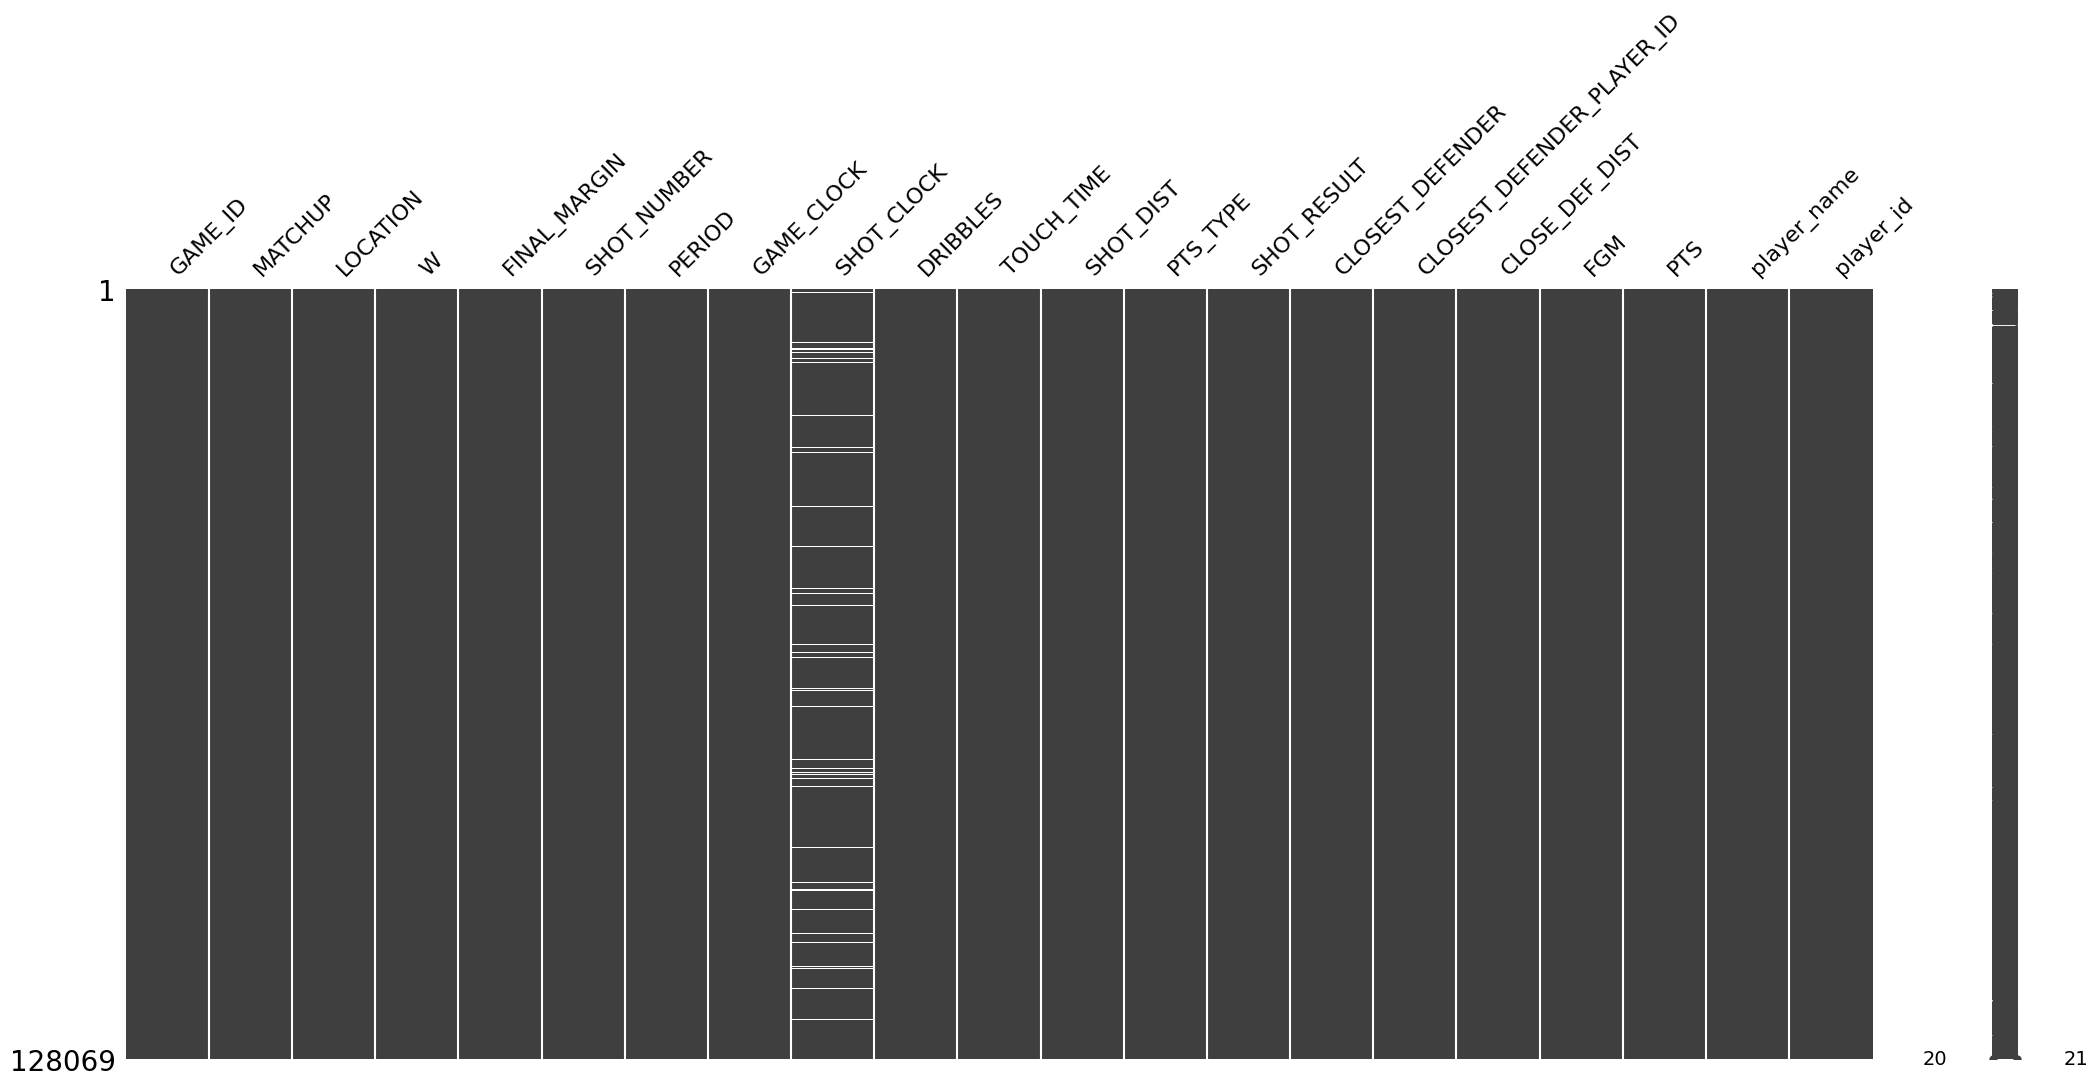

In [ ]:
#a graph to clearly show the null values
msno.matrix(df)

In [ ]:
df.isnull().sum() #check for null
#5567 null values found in SHOT_CLOCK

,0
GAME_ID,0
MATCHUP,0
LOCATION,0
W,0
FINAL_MARGIN,0
SHOT_NUMBER,0
PERIOD,0
GAME_CLOCK,0
SHOT_CLOCK,5567
DRIBBLES,0


In [ ]:
#fixing the null values found in SHOT_CLOCK using the mean method
df["SHOT_CLOCK"].fillna(df["SHOT_CLOCK"].mean(), inplace=True) #inplace = true to modify the original dataset
df.isnull().sum() #check for null

/tmp/ipykernel_604/3942575036.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["SHOT_CLOCK"].fillna(df["SHOT_CLOCK"].mean(), inplace=True) #inplace = true to modify the original dataset


,0
GAME_ID,0
MATCHUP,0
LOCATION,0
W,0
FINAL_MARGIN,0
SHOT_NUMBER,0
PERIOD,0
GAME_CLOCK,0
SHOT_CLOCK,0
DRIBBLES,0


In [ ]:
print(df.duplicated().sum())# to check for duplicates in rows (whole duplicated rows)

0


In [ ]:
df.drop_duplicates(inplace=True) #to drop the duplicaes and modify the original dataset
df.head(5)

,GAME_ID,MATCHUP,LOCATION,W,FINAL_MARGIN,SHOT_NUMBER,PERIOD,GAME_CLOCK,SHOT_CLOCK,DRIBBLES,...,SHOT_DIST,PTS_TYPE,SHOT_RESULT,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,FGM,PTS,player_name,player_id
0,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,1,1,1:09,10.800000,2,...,7.7,2,made,"Anderson, Alan",101187,1.3,1,2,brian roberts,203148
1,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,2,1,0:14,3.400000,0,...,28.2,3,missed,"Bogdanovic, Bojan",202711,6.1,0,0,brian roberts,203148
2,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,3,1,0:00,12.453344,3,...,10.1,2,missed,"Bogdanovic, Bojan",202711,0.9,0,0,brian roberts,203148
3,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,4,2,11:47,10.300000,2,...,17.2,2,missed,"Brown, Markel",203900,3.4,0,0,brian roberts,203148
4,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,5,2,10:34,10.900000,2,...,3.7,2,missed,"Young, Thaddeus",201152,1.1,0,0,brian roberts,203148


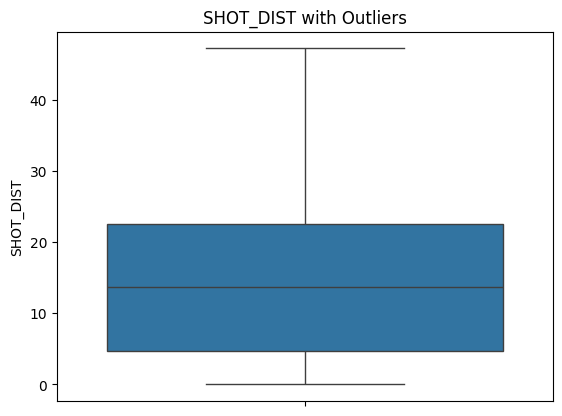

In [ ]:
#to check for outliers
sns.boxplot(y=df["SHOT_DIST"], showfliers=True)


plt.title("SHOT_DIST with Outliers")
plt.show()

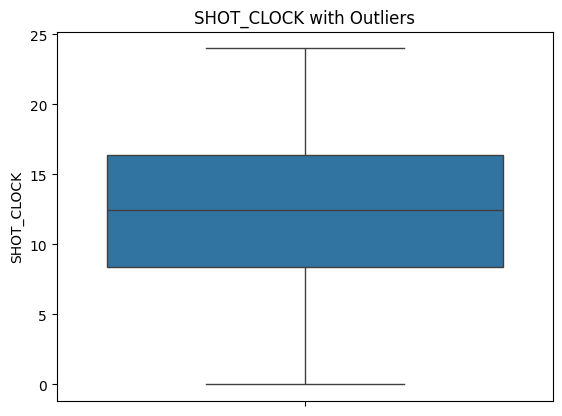

In [ ]:
sns.boxplot(y=df["SHOT_CLOCK"], showfliers=True)
plt.title("SHOT_CLOCK with Outliers")
plt.show()

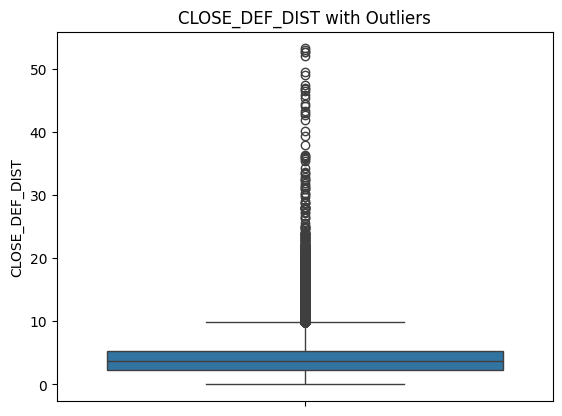

In [ ]:
sns.boxplot(y=df["CLOSE_DEF_DIST"], showfliers=True)
plt.title("CLOSE_DEF_DIST with Outliers")
plt.show()

In [ ]:
# Cap extreme values at 99th percentile
upper = df["CLOSE_DEF_DIST"].quantile(0.99)

df["CLOSE_DEF_DIST"] = df["CLOSE_DEF_DIST"].clip(upper=upper)

In [ ]:
Q1 = df["CLOSE_DEF_DIST"].quantile(0.25)
Q3 = df["CLOSE_DEF_DIST"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["CLOSE_DEF_DIST"] = df["CLOSE_DEF_DIST"].clip(lower=lower, upper=upper)

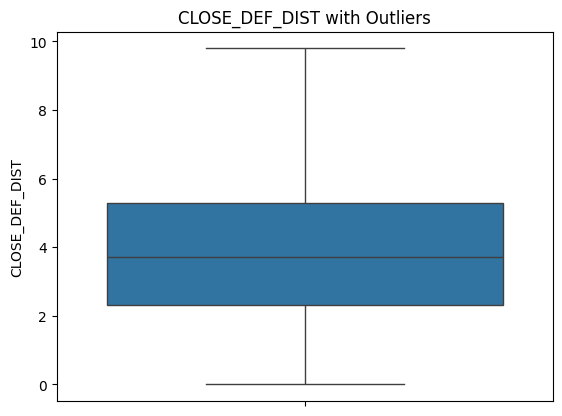

In [ ]:
sns.boxplot(y=df["CLOSE_DEF_DIST"], showfliers=True)
plt.title("CLOSE_DEF_DIST with Outliers")
plt.show()

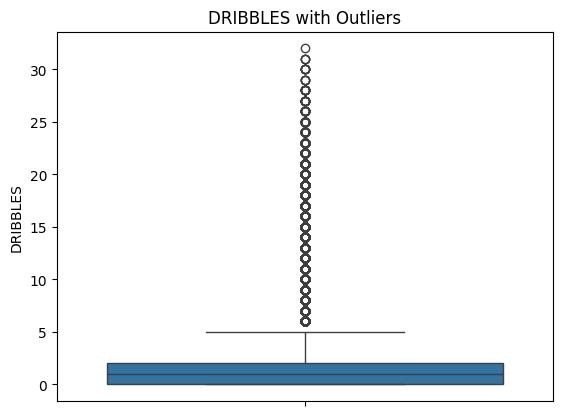

In [ ]:
sns.boxplot(y=df["DRIBBLES"], showfliers=True)
plt.title("DRIBBLES with Outliers")
plt.show()

In [ ]:
upper = df["DRIBBLES"].quantile(0.99)

df["DRIBBLES"] = df["DRIBBLES"].clip(upper=upper)

In [ ]:
Q1 = df["DRIBBLES"].quantile(0.25)
Q3 = df["DRIBBLES"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["DRIBBLES"] = df["DRIBBLES"].clip(lower=lower, upper=upper)

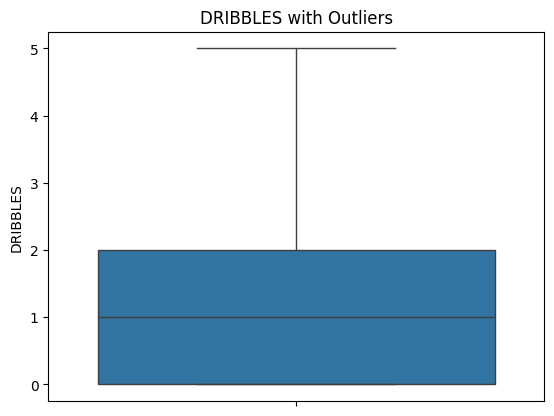

In [ ]:
sns.boxplot(y=df["DRIBBLES"], showfliers=True)
plt.title("DRIBBLES with Outliers")
plt.show()

### **converting catagorical columns**

In [ ]:
df['SHOT_RESULT'] = df['SHOT_RESULT'].map({'missed': 0, 'made': 1})

In [ ]:
def defender_pressure(dist):
    if dist < 2:
        return 0   # Tight
    elif dist > 4:
        return 2   # Open
    else:
        return 1   # Contested

df['CLOSE_DEF_DIST'] = df['CLOSE_DEF_DIST'].apply(defender_pressure)

In [ ]:
mapping = {
    0: 'Tight',
    1: 'Contested',
    2: 'Open'
}

df['CLOSE_DEF_DIST_LABEL'] = df['CLOSE_DEF_DIST'].map(mapping)

In [ ]:
df = df.drop(columns=['CLOSE_DEF_DIST'])

In [ ]:
#label encoding close midrange threepoint
def shot_zone(dist):
    if dist < 8:
        return 0 # Close
    elif dist <= 22:
        return 1 #Mid-Range
    else:
        return 2 #Three-Point

df['Shot Zone Group'] = df['SHOT_DIST'].apply(shot_zone)

In [ ]:
mapping = {
    0: 'Close',
    1: 'Mid-Range',
    2: 'Three-Point'
}

df['Shot Zone Group'] = df['Shot Zone Group'].map(mapping)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128069 entries, 0 to 128068
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   GAME_ID                     128069 non-null  int64  
 1   MATCHUP                     128069 non-null  object 
 2   LOCATION                    128069 non-null  object 
 3   W                           128069 non-null  object 
 4   FINAL_MARGIN                128069 non-null  int64  
 5   SHOT_NUMBER                 128069 non-null  int64  
 6   PERIOD                      128069 non-null  int64  
 7   GAME_CLOCK                  128069 non-null  object 
 8   SHOT_CLOCK                  128069 non-null  float64
 9   DRIBBLES                    128069 non-null  int64  
 10  TOUCH_TIME                  128069 non-null  float64
 11  SHOT_DIST                   128069 non-null  float64
 12  PTS_TYPE                    128069 non-null  int64  
 13  SHOT_RESULT   

In [ ]:
df["CLOSE_DEF_DIST_LABEL"]

,CLOSE_DEF_DIST_LABEL
0,Tight
1,Open
2,Tight
3,Contested
4,Tight
...,...
128064,Tight
128065,Tight
128066,Open
128067,Contested


### **renaming columns**

In [ ]:
df = df.rename(columns={
    'SHOT_DIST':'shot_distance',
    'GAME_ID': 'game_id',
    'MATCHUP': 'matchup',
    'LOCATION': 'home_away',
    'W': 'win_loss',
    'FINAL_MARGIN': 'final_margin',
    'SHOT_NUMBER': 'shot_number',
    'PERIOD': 'quarter',
    'GAME_CLOCK': 'game_clock',
    'SHOT_CLOCK': 'shot_clock',
    'DRIBBLES': 'dribbles',
    'TOUCH_TIME': 'touch_time',
    'PTS_TYPE': 'shot_type',
    'SHOT_RESULT': 'shot_result',
    'CLOSEST_DEFENDER': 'closest_defender_name',
    'CLOSEST_DEFENDER_PLAYER_ID': 'closest_defender_id',
    'FGM': 'field_goal_made',
    'PTS': 'points',
    'player_name': 'player_name',
    'player_id': 'player_id',
    'CLOSE_DEF_DIST_LABEL': 'defender_pressure',
    'Shot Zone Group': 'shot_zone_group'
})

In [ ]:
df.head(5)

,game_id,matchup,home_away,win_loss,final_margin,shot_number,quarter,game_clock,shot_clock,dribbles,...,shot_type,shot_result,closest_defender_name,closest_defender_id,field_goal_made,points,player_name,player_id,defender_pressure,shot_zone_group
0,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,1,1,1:09,10.800000,2,...,2,1,"Anderson, Alan",101187,1,2,brian roberts,203148,Tight,Close
1,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,2,1,0:14,3.400000,0,...,3,0,"Bogdanovic, Bojan",202711,0,0,brian roberts,203148,Open,Three-Point
2,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,3,1,0:00,12.453344,3,...,2,0,"Bogdanovic, Bojan",202711,0,0,brian roberts,203148,Tight,Mid-Range
3,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,4,2,11:47,10.300000,2,...,2,0,"Brown, Markel",203900,0,0,brian roberts,203148,Contested,Mid-Range
4,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,5,2,10:34,10.900000,2,...,2,0,"Young, Thaddeus",201152,0,0,brian roberts,203148,Tight,Close


In [ ]:
df["shot_distance"]

,shot_distance
0,7.7
1,28.2
2,10.1
3,17.2
4,3.7
...,...
128064,8.7
128065,0.6
128066,16.9
128067,18.3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128069 entries, 0 to 128068
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   game_id                128069 non-null  int64  
 1   matchup                128069 non-null  object 
 2   home_away              128069 non-null  object 
 3   win_loss               128069 non-null  object 
 4   final_margin           128069 non-null  int64  
 5   shot_number            128069 non-null  int64  
 6   quarter                128069 non-null  int64  
 7   game_clock             128069 non-null  object 
 8   shot_clock             128069 non-null  float64
 9   dribbles               128069 non-null  int64  
 10  touch_time             128069 non-null  float64
 11  shot_distance          128069 non-null  float64
 12  shot_type              128069 non-null  int64  
 13  shot_result            128069 non-null  int64  
 14  closest_defender_name  128069 non-nu

Splitting the coulmn

In [ ]:
df["matchup"]

,matchup
0,"MAR 04, 2015 - CHA @ BKN"
1,"MAR 04, 2015 - CHA @ BKN"
2,"MAR 04, 2015 - CHA @ BKN"
3,"MAR 04, 2015 - CHA @ BKN"
4,"MAR 04, 2015 - CHA @ BKN"
...,...
128064,"OCT 29, 2014 - BKN @ BOS"
128065,"OCT 29, 2014 - BKN @ BOS"
128066,"OCT 29, 2014 - BKN @ BOS"
128067,"OCT 29, 2014 - BKN @ BOS"


In [ ]:
df['matchup'] = df['matchup'].str.replace('vs\.', '@', regex=True)


<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_604/3159216152.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['matchup'] = df['matchup'].str.replace('vs\.', '@', regex=True)


In [ ]:
df[['game_date', 'matchup']] = df['matchup'].str.split(' - ', expand=True)

In [ ]:
df[['away_team', 'home_team']] = df['matchup'].str.split(' @ ', expand=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128069 entries, 0 to 128068
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   game_id                128069 non-null  int64  
 1   matchup                128069 non-null  object 
 2   home_away              128069 non-null  object 
 3   win_loss               128069 non-null  object 
 4   final_margin           128069 non-null  int64  
 5   shot_number            128069 non-null  int64  
 6   quarter                128069 non-null  int64  
 7   game_clock             128069 non-null  object 
 8   shot_clock             128069 non-null  float64
 9   dribbles               128069 non-null  int64  
 10  touch_time             128069 non-null  float64
 11  shot_distance          128069 non-null  float64
 12  shot_type              128069 non-null  int64  
 13  shot_result            128069 non-null  int64  
 14  closest_defender_name  128069 non-nu

In [ ]:
df["game_date"]

,game_date
0,"MAR 04, 2015"
1,"MAR 04, 2015"
2,"MAR 04, 2015"
3,"MAR 04, 2015"
4,"MAR 04, 2015"
...,...
128064,"OCT 29, 2014"
128065,"OCT 29, 2014"
128066,"OCT 29, 2014"
128067,"OCT 29, 2014"


In [ ]:
df["matchup"].unique()

array(['CHA @ BKN', 'CHA @ LAL', 'CHA @ ORL', 'CHA @ BOS', 'CHA @ CHI',
       'CHA @ DAL', 'CHA @ OKC', 'CHA @ DET', 'CHA @ IND', 'CHA @ PHI',
       'CHA @ WAS', 'CHA @ DEN', 'CHA @ SAS', 'CHA @ NYK', 'CHA @ CLE',
       'CHA @ MIA', 'CHA @ MIN', 'CHA @ TOR', 'CHA @ NOP', 'CHA @ HOU',
       'CHA @ MIL', 'CHA @ UTA', 'CHA @ PHX', 'CHA @ MEM', 'CHA @ ATL',
       'CHA @ GSW', 'CHA @ POR', 'CHA @ LAC', 'MIN @ DEN', 'MIN @ LAC',
       'MIN @ MEM', 'MIN @ CHI', 'MIN @ WAS', 'MIN @ PHX', 'UTA @ BOS',
       'UTA @ MEM', 'UTA @ MIL', 'UTA @ DEN', 'UTA @ LAL', 'UTA @ SAS',
       'UTA @ POR', 'UTA @ DAL', 'UTA @ NOP', 'UTA @ SAC', 'UTA @ PHX',
       'UTA @ GSW', 'UTA @ LAC', 'UTA @ BKN', 'UTA @ CLE', 'UTA @ HOU',
       'UTA @ OKC', 'UTA @ CHI', 'UTA @ IND', 'UTA @ MIN', 'UTA @ ATL',
       'UTA @ PHI', 'UTA @ CHA', 'UTA @ ORL', 'UTA @ MIA', 'UTA @ WAS',
       'UTA @ TOR', 'UTA @ NYK', 'UTA @ DET', 'OKC @ PHI', 'OKC @ LAL',
       'OKC @ PHX', 'OKC @ IND', 'OKC @ DEN', 'OKC @ CHA', 'LAL 

In [ ]:
df['game_date'] = pd.to_datetime(df['game_date'])

/tmp/ipykernel_604/3226137798.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['game_date'] = pd.to_datetime(df['game_date'])


In [ ]:
df["game_date"]

,game_date
0,2015-03-04
1,2015-03-04
2,2015-03-04
3,2015-03-04
4,2015-03-04
...,...
128064,2014-10-29
128065,2014-10-29
128066,2014-10-29
128067,2014-10-29


### **step 4 Data Analysis (Exploratory Data Analysis)**

In [ ]:
# shot distribution by zone, player, team, and quarter.
full = df.groupby(['home_team', 'player_name', 'shot_zone_group', 'quarter']).size().reset_index(name='shots')

print(full)

      home_team    player_name shot_zone_group  quarter  shots
0           ATL   aaron brooks           Close        2      2
1           ATL   aaron brooks           Close        4      1
2           ATL   aaron brooks       Mid-Range        1      1
3           ATL   aaron brooks       Mid-Range        2      1
4           ATL   aaron brooks       Mid-Range        4      1
...         ...            ...             ...      ...    ...
52831       WAS  zaza pachulia           Close        3      1
52832       WAS  zaza pachulia       Mid-Range        1      3
52833       WAS  zaza pachulia       Mid-Range        2      2
52834       WAS  zaza pachulia       Mid-Range        3      3
52835       WAS  zaza pachulia       Mid-Range        4      1

[52836 rows x 5 columns]


In [ ]:
#Calculate shooting percentages per zone and per player
df.groupby(['player_name', 'shot_zone_group'])['shot_result'].mean()

player_name    shot_zone_group
aaron brooks   Close              0.462687
               Mid-Range          0.375000
               Three-Point        0.397321
aaron gordon   Close              0.633333
               Mid-Range          0.380952
                                    ...   
zach randolph  Mid-Range          0.370892
               Three-Point        0.545455
zaza pachulia  Close              0.466667
               Mid-Range          0.402174
               Three-Point        0.000000
Name: shot_result, Length: 823, dtype: float64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128069 entries, 0 to 128068
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   game_id                128069 non-null  int64         
 1   matchup                128069 non-null  object        
 2   home_away              128069 non-null  object        
 3   win_loss               128069 non-null  object        
 4   final_margin           128069 non-null  int64         
 5   shot_number            128069 non-null  int64         
 6   quarter                128069 non-null  int64         
 7   game_clock             128069 non-null  object        
 8   shot_clock             128069 non-null  float64       
 9   dribbles               128069 non-null  int64         
 10  touch_time             128069 non-null  float64       
 11  shot_distance          128069 non-null  float64       
 12  shot_type              128069 non-null  int6

In [ ]:
df[["shot_distance","shot_type","shot_zone_group"]]

,shot_distance,shot_type,shot_zone_group
0,7.7,2,Close
1,28.2,3,Three-Point
2,10.1,2,Mid-Range
3,17.2,2,Mid-Range
4,3.7,2,Close
...,...,...,...
128064,8.7,2,Mid-Range
128065,0.6,2,Close
128066,16.9,2,Mid-Range
128067,18.3,2,Mid-Range


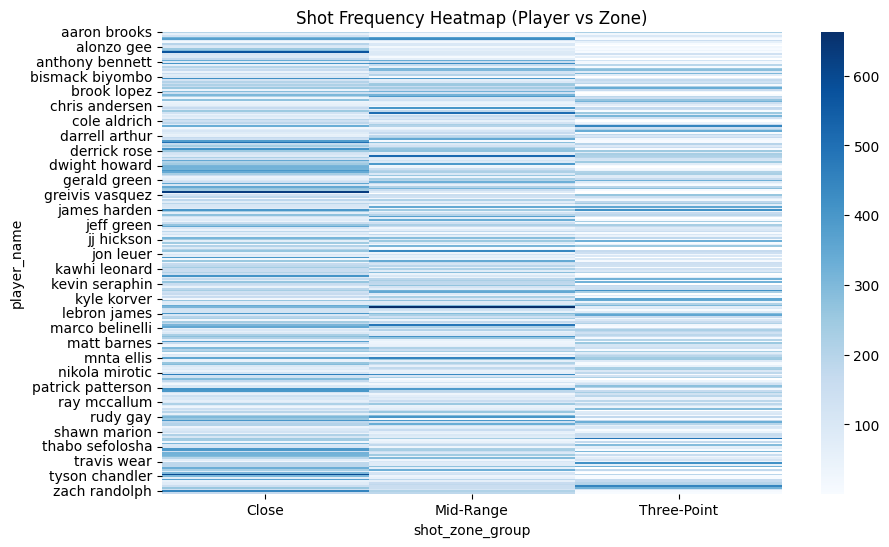

In [ ]:

heatmap_data = df.pivot_table(
    index='player_name',
    columns='shot_zone_group',
    values='shot_result',
    aggfunc='count'
)

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap="Blues")
plt.title("Shot Frequency Heatmap (Player vs Zone)")
plt.show()

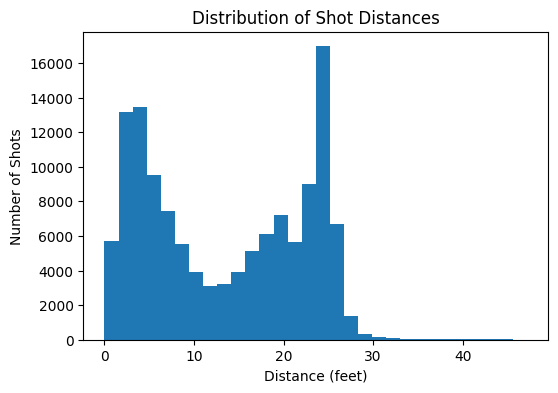

In [ ]:
#Distribution of shot distances
plt.figure(figsize=(6,4))
plt.hist(df['shot_distance'], bins=30)
plt.title("Distribution of Shot Distances")
plt.xlabel("Distance (feet)")
plt.ylabel("Number of Shots")
plt.show()

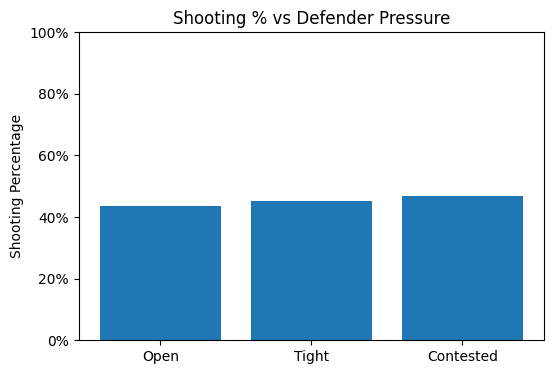

In [ ]:
#Defender pressure vs shot result
defender_effect = (
    df.groupby('defender_pressure')['shot_result']
    .mean()
    .reindex(['Open', 'Tight', 'Contested'])  # correct order
)

plt.figure(figsize=(6,4))
plt.bar(defender_effect.index, defender_effect.values)

plt.title("Shooting % vs Defender Pressure")
plt.ylabel("Shooting Percentage")
plt.ylim(0,1)

plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plt.show()

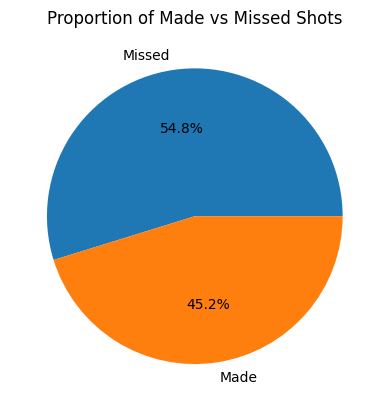

In [ ]:
#Made vs Missed shots
shot_counts = df['shot_result'].value_counts()

plt.pie(
    shot_counts,
    labels=['Missed', 'Made'],
    autopct='%1.1f%%'
)

plt.title("Proportion of Made vs Missed Shots")
plt.show()

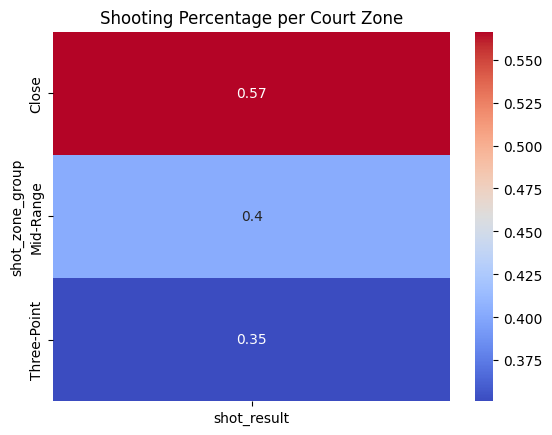

In [ ]:

zone_heatmap = df.pivot_table(
    index='shot_zone_group',
    values='shot_result',
    aggfunc='mean'
)

sns.heatmap(zone_heatmap, annot=True, cmap="coolwarm")
plt.title("Shooting Percentage per Court Zone")
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128069 entries, 0 to 128068
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   game_id                128069 non-null  int64         
 1   matchup                128069 non-null  object        
 2   home_away              128069 non-null  object        
 3   win_loss               128069 non-null  object        
 4   final_margin           128069 non-null  int64         
 5   shot_number            128069 non-null  int64         
 6   quarter                128069 non-null  int64         
 7   game_clock             128069 non-null  object        
 8   shot_clock             128069 non-null  float64       
 9   dribbles               128069 non-null  int64         
 10  touch_time             128069 non-null  float64       
 11  shot_distance          128069 non-null  float64       
 12  shot_type              128069 non-null  int6

### **step 5**

In [ ]:
#k-mean
player_features = df.groupby("player_id").agg({

    "shot_distance": "mean",          # average shot distance
    "field_goal_made": "mean",        # shooting percentage
    "shot_type": "mean",              # proxy for 3PT attempt rate
    "dribbles": "mean",               # shot creation
    "touch_time": "mean",             # usage / ball control

    "shot_result": "count"            # volume (optional)
}).rename(columns={

    "shot_distance": "average_shot_distance",
    "field_goal_made": "shooting_percentage",
    "shot_type": "three_point_attempt_rate",
    "dribbles": "avg_dribbles",
    "touch_time": "avg_touch_time",
    "shot_result": "shot_volume"
})

In [ ]:
#k-mean

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = player_features[[
    "shooting_percentage",
    "average_shot_distance",
    "three_point_attempt_rate",
    "avg_dribbles",
    "avg_touch_time"
]]

scaler = StandardScaler()
X = scaler.fit_transform(features)

k = 3
km = KMeans(n_clusters=k, random_state=0)
player_features["Cluster"] = km.fit_predict(X)

print(km.cluster_centers_)
print(player_features["Cluster"].value_counts())

[[ 0.88703163 -1.0601886  -1.07087842 -0.6971194  -0.58272246]
 [-0.41218856  0.28961627  0.11438432  1.45195015  1.44072615]
 [-0.53292265  0.78252675  0.91814864 -0.38993765 -0.48873268]]
Cluster
2    106
0     99
1     76
Name: count, dtype: int64


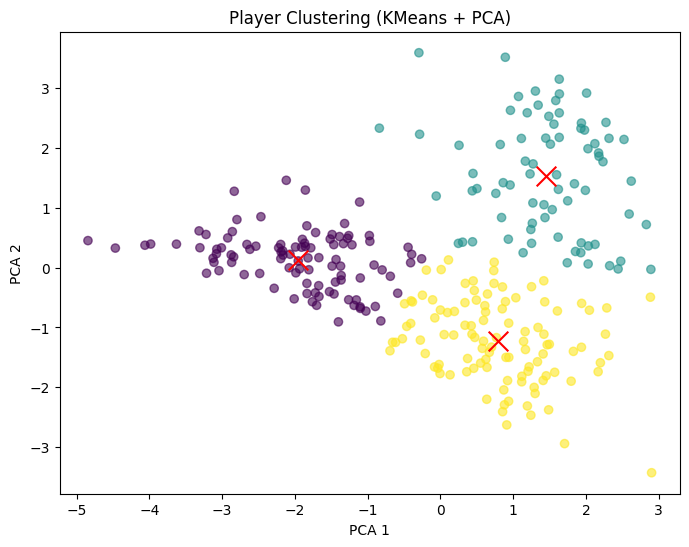

In [ ]:
#k-mean

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)
centers_2d = pca.transform(km.cluster_centers_)

plt.figure(figsize=(8,6))

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=player_features["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.scatter(
    centers_2d[:, 0],
    centers_2d[:, 1],
    c="red",
    marker="x",
    s=200
)

plt.title("Player Clustering (KMeans + PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

**Elbow method**

In [ ]:
features = ['shot_distance', 'shot_type', 'shot_zone_group']
df_clean = df[features].dropna().copy()

In [ ]:
df_clean['shot_type'] = df_clean['shot_type'].astype('category').cat.codes   # converting categories column to numbers
df_clean['shot_zone_group'] = df_clean['shot_zone_group'].astype('category').cat.codes

In [ ]:
from sklearn.preprocessing import StandardScaler #make columns effect in the same %

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

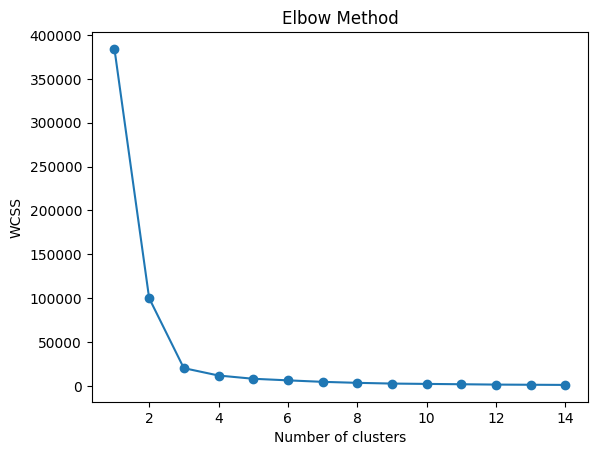

In [ ]:
wcss = []

for k in range(1, 15):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) #el 20rb

plt.plot(range(1, 15), wcss, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()





**classification by desicion tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [ ]:
features = [
    'shot_distance',
    'shot_type',
    'shot_zone_group',
    'defender_pressure'
]

target = 'field_goal_made'


In [ ]:
cols = features + [target]
cols = [col for col in cols if col in df.columns] #filter

data = df[cols].dropna().copy()

In [ ]:
le = LabelEncoder() #convert text to numbers

for col in features:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col]) #7asab el appearence


In [ ]:
X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train) #training


DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred)) # in total
print("Precision:", precision_score(y_test, y_pred)) #specific
print("Recall:", recall_score(y_test, y_pred)) #find bifawit
print("F1-Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6099789177793394
Precision: 0.6197411003236246
Recall: 0.36262695816835944
F1-Score: 0.4575369244135534

Classification Report:

              precision    recall  f1-score   support

           0       0.61      0.82      0.70     13996
           1       0.62      0.36      0.46     11618

    accuracy                           0.61     25614
   macro avg       0.61      0.59      0.58     25614
weighted avg       0.61      0.61      0.59     25614


Confusion Matrix:

[[11411  2585]
 [ 7405  4213]]


**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-Score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

RF Accuracy: 0.6094713828375108
Precision: 0.6153077252606026
Recall: 0.3708899982785333
F1-Score: 0.46281080500510174

Classification Report:

              precision    recall  f1-score   support

           0       0.61      0.81      0.69     13996
           1       0.62      0.37      0.46     11618

    accuracy                           0.61     25614
   macro avg       0.61      0.59      0.58     25614
weighted avg       0.61      0.61      0.59     25614


Confusion Matrix:

[[11302  2694]
 [ 7309  4309]]


In [ ]:
importances = model.feature_importances_ #the most important in effect

for i, col in enumerate(X.columns):
    print(col, importances[i])

shot_distance 0.770890402800686
shot_type 0.018402784545042822
shot_zone_group 0.00015325680861407695
defender_pressure 0.21055355584565716
